# Homework 2

**Before you start:** Read Chapter 3 Data Visualization and Chapter 4 Dimension Reduction in the textbook.

**Note:** Please make sure your plots are complete and presentable with a title, proper axis names, labels and legends if applicable.

Please enter the code along with your comments in the **TODO** sections.

Please refer to the **Hint** section if you do not know where to start. 

Alternative solutions are welcomed.

## Part 1: Advanced Data Visualization

### Problem 1 ##

**Dataset:** [Mismanaged waste](https://ourworldindata.org/grapher/mismanaged-plastic-waste?tab=chart&time=earliest..latest)

**Introduction:** Jambeck et al. quantified municipal and plastic waste streams from coastal populations in 2010 with projections to the year 2025. The authors define mismanaged and inadequately managed waste as follows: "mismanaged waste is material that is either littered or inadequately disposed. Inadequately disposed waste is not formally managed and includes disposal in dumps or open, uncontrolled landfills, where it is not fully contained. Mismanaged waste could eventually enter the ocean via inland waterways,
wastewater outflows, and transport by wind or tides. "

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [2]:
#Load the dataset
df = pd.read_csv("mismanaged-waste-global-total.csv") 
df.head()

,Entity,Code,Year,Mismanaged waste (% global total) (% of global total)
0,Albania,ALB,2010,0.0933
1,Algeria,DZA,2010,1.6347
2,Angola,AGO,2010,0.1964
3,Anguilla,AIA,2010,0.0002
4,Antigua and Barbuda,ATG,2010,0.0039


**TODO1:**

*  Use a choropleth map to present the amount of mismanaged waste by country *(Highlight only the top 5 countries)*
*   The label (hover) should include the country name and percentage of mismanaged waste
*  Interpret your key findings from the map graph
*  Considering the manufacturing volume of each country, is this graph misleading?

In [3]:
import datetime
from datetime import date

df['Year'] = pd.to_datetime(df['Year'],errors='coerce')


In [4]:
df.isna().sum()

Entity                                                   0
Code                                                     0
Year                                                     0
Mismanaged waste (% global total) (% of global total)    0
dtype: int64

In [5]:
df.dtypes

Entity                                                           object
Code                                                             object
Year                                                     datetime64[ns]
Mismanaged waste (% global total) (% of global total)           float64
dtype: object

In [6]:
import geopandas as gpd

world = gpd.read_file('/Users/mll/ne_110m_admin_0_countries.shp')
world

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,Admin-0 country,1,5,Republic of Serbia,SRB,0,2,Sovereign country,1,Republic of Serbia,...,None,None,None,None,None,None,None,None,None,"POLYGON ((18.82982 45.90887, 18.82984 45.90888..."
173,Admin-0 country,1,6,Montenegro,MNE,0,2,Sovereign country,1,Montenegro,...,None,None,None,None,None,None,None,None,None,"POLYGON ((20.0707 42.58863, 19.80161 42.50009,..."
174,Admin-0 country,1,6,Kosovo,KOS,0,2,Disputed,1,Kosovo,...,Admin-0 country,Unrecognized,Admin-0 country,Unrecognized,Admin-0 country,Admin-0 country,Admin-0 country,Admin-0 country,Unrecognized,"POLYGON ((20.59025 41.85541, 20.52295 42.21787..."
175,Admin-0 country,1,5,Trinidad and Tobago,TTO,0,2,Sovereign country,1,Trinidad and Tobago,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-61.68 10.76, -61.105 10.89, -60.895..."


**Hint:** 

* The variable "code" contains [three letters ISO country codes](https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3). 
* [Use the built-in country code to create a choropleth map.](https://plotly.com/python/choropleth-maps/#using-builtin-country-and-state-geometries)



In [7]:
world.isna().sum()

featurecla      0
scalerank       0
LABELRANK       0
SOVEREIGNT      0
SOV_A3          0
             ... 
FCLASS_NL     173
FCLASS_SE     174
FCLASS_BD     171
FCLASS_UA     174
geometry        0
Length: 169, dtype: int64

In [8]:
world.dropna(inplace=True,axis=1)

In [9]:
df.rename(columns={'Code':'SOV_A3','Mismanaged waste (% global total) (% of global total)':'Mismanaged Waste'},inplace=True)

In [10]:
df.columns

Index(['Entity', 'SOV_A3', 'Year', 'Mismanaged Waste'], dtype='object')

In [11]:
world = world.merge(df,on='SOV_A3',how='left')

In [12]:
world.head(2)

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,ADMIN,ADM0_A3,...,NAME_UR,NAME_VI,NAME_ZH,NAME_ZHT,FCLASS_ISO,FCLASS_TLC,geometry,Entity,Year,Mismanaged Waste
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,Fiji,FJI,...,فجی,Fiji,斐济,斐濟,Admin-0 country,Admin-0 country,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...",Fiji,1970-01-01 00:00:00.000002010,0.1547
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,United Republic of Tanzania,TZA,...,تنزانیہ,Tanzania,坦桑尼亚,坦尚尼亞,Admin-0 country,Admin-0 country,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3...",Tanzania,1970-01-01 00:00:00.000002010,0.1526


In [13]:
print(world[['SOV_A3', 'Mismanaged Waste']].head(10)) 
print(world['Mismanaged Waste'].isna().sum()) 

  SOV_A3  Mismanaged Waste
0    FJI            0.1547
1    TZA            0.1526
2    SAH               NaN
3    CAN            0.0250
4    US1               NaN
5    KA1               NaN
6    UZB               NaN
7    PNG            0.2821
8    IDN           10.1019
9    ARG            0.4955
63


In [14]:
world['Mismanaged Waste'].fillna(0,inplace=True)

In [15]:
print(world['Mismanaged Waste'].isna().sum())

0


In [16]:
top5 = df.nlargest(5,'Mismanaged Waste')

In [17]:
world1 = world.merge(df,on='SOV_A3',how='inner')
world1.shape

(114, 134)

In [18]:
top5

,Entity,SOV_A3,Year,Mismanaged Waste
28,China,CHN,1970-01-01 00:00:00.000002010,27.6966
80,Indonesia,IDN,1970-01-01 00:00:00.000002010,10.1019
134,Philippines,PHL,1970-01-01 00:00:00.000002010,5.9153
184,Vietnam,VNM,1970-01-01 00:00:00.000002010,5.7588
161,Sri Lanka,LKA,1970-01-01 00:00:00.000002010,4.9968


In [19]:
world.head(1)

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,ADMIN,ADM0_A3,...,NAME_UR,NAME_VI,NAME_ZH,NAME_ZHT,FCLASS_ISO,FCLASS_TLC,geometry,Entity,Year,Mismanaged Waste
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,Fiji,FJI,...,فجی,Fiji,斐济,斐濟,Admin-0 country,Admin-0 country,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...",Fiji,1970-01-01 00:00:00.000002010,0.1547


In [20]:
import pandas as pd

In [21]:
top5new = world.nlargest(5,'Mismanaged Waste')

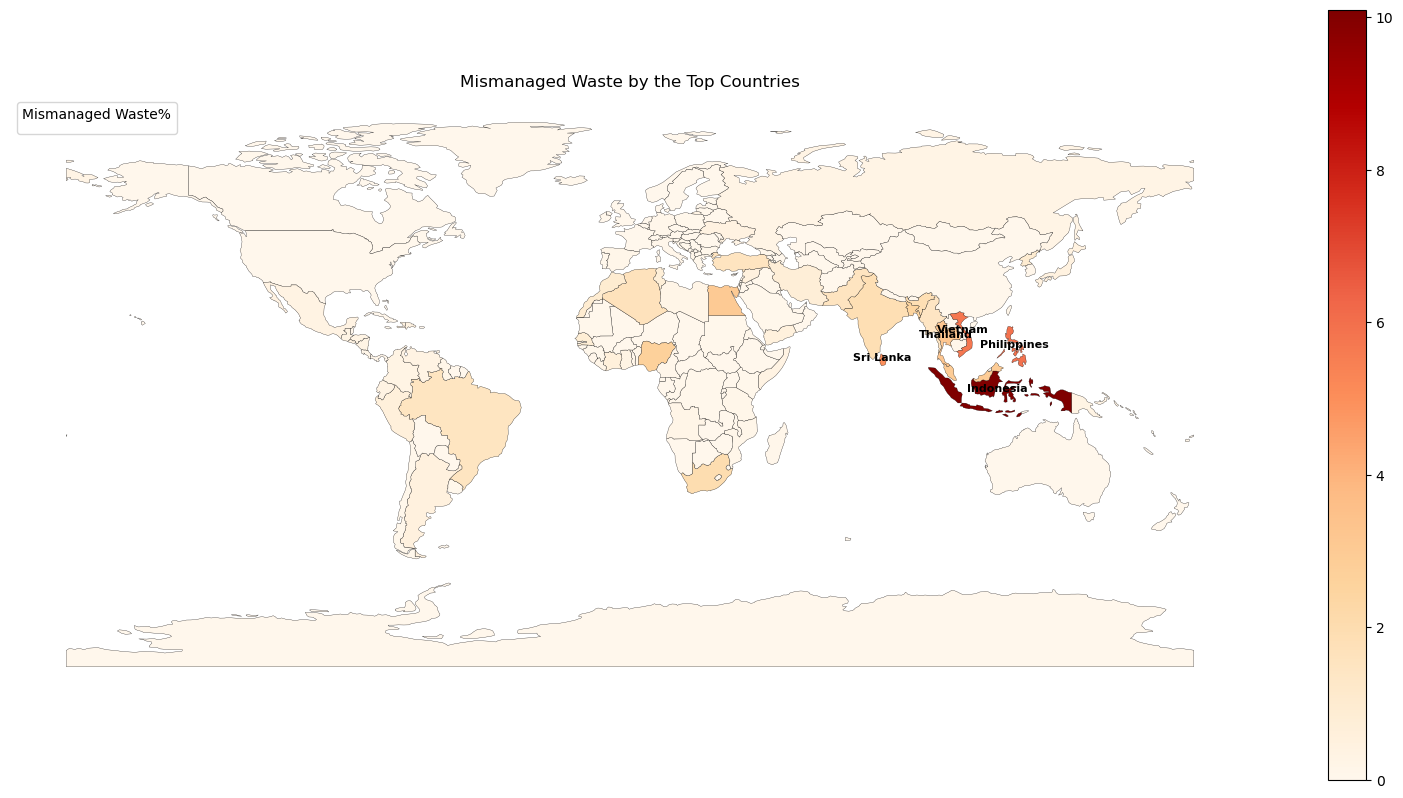

In [22]:
fig,ax = plt.subplots(figsize=(20,10))
world.plot(column='Mismanaged Waste',cmap="OrRd",linewidth=0.2,edgecolor='black',
           legend=True,ax=ax)

for i,row in top5new.iterrows():
    if pd.notnull(row['Mismanaged Waste']):
        centroid = row.geometry.centroid
        ax.annotate(text=row['NAME'], xy=(centroid.x, centroid.y),
                    fontsize=8, ha='center', color='black', weight='bold')




ax.set_title("Mismanaged Waste by the Top Countries")
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

handles,labels = ax.get_legend_handles_labels()
ax.legend(handles,labels,title='Mismanaged Waste%',loc='upper left')
plt.show()

### Problem 2 ##

**Dataset:** [Plastic disposal dataset](https://ourworldindata.org/plastic-pollution)

**Information:** Plastic disposal dataset methods shows how has global plastic waste disposal method changed over time. In the chart we see the share of global plastic waste that is discarded, recycled or incinerated from 1980 through to 2015.


In [23]:
#Load the dataset
df1 = pd.read_excel("activity.xlsx") 
df1.head()

,year,Value,Type
0,1960,88.1,Generation
1,1960,NaN,Composting*
2,1960,5.6,Recycling
3,1960,0.0,Combustion with energy recovery
4,1960,82.5,Landfilling and other disposal


**TODO1:**
*  Use an animated bar chart to indicate the change of trash disposal method through the years
*  Interpret your key findings from the graph


In [24]:
df1['Type'].value_counts()

Type
Generation                         10
Composting*                        10
Recycling                          10
Combustion with energy recovery    10
Landfilling and other disposal     10
Name: count, dtype: int64

In [25]:
fig = px.bar(df1,x='year',y='Value',color='Type',animation_frame='year',
             labels={'Value':'Amount','Type':'Disposal Method'},
             title='Disposal Methods Over Time')
fig.show()

**Hint:** [Animated Bar Charts with Plotly Express](https://plotly.com/python/animations/#animated-bar-charts-with-plotly-express)




**TODO2:**
*  Suggest and show a better way to visualize the  data (choose the most approporiate visualization for this use case)

In [26]:
fig1 = px.area(df1,x='year',y='Value',color='Type',
               labels={'Value':'Amount','Type':'Disposal Method'},title='Disposal Change methods thru the years')
fig1.show()

### Problem 3 ##

**Dataset:** [Global Fortune 500](https://www.kaggle.com/edgarhuichen/fortune-global-500)

**Introduction:** Fortune Global 500 List is a list of largest corporations worldwide which are measured by their total fiscal year revenues. Companies rankings sorted by total revenues for their respective fiscal years ended on or before March 31 of the relevant year.

In [27]:
#Import packages
import pandas as pd
import numpy as np
import plotly.express as px

#upload file into google colab session
df3 = pd.read_csv("Global Fortune 500.csv") 
df3.head()

,Rank,Company Name,Country,Number of Employees,Previous Rank,Revenues($millions),Revenue Change,Profits($millions),Profit Change,Assets($millions),Unnamed: 10,Unnamed: 11
0,1,Walmart,USA,"2,300,000",1,485873,0.80%,13643,-7.20%,198825,NaN,NaN
1,2,State Grid,China,"926,067",2,315199,-4.40%,9571.3,-6.20%,489838,NaN,NaN
2,3,Sinopec Group,China,"713,288",4,267518,-9.10%,1257.9,-65.00%,310726,NaN,NaN
3,4,China National Petroleum,China,"1,512,048",3,262573,-12.30%,1867.5,-73.70%,585619,NaN,NaN
4,5,Toyota Motor,Japan,"364,445",8,254694,7.70%,16899.3,-12.30%,437575,NaN,NaN


**TODO1:**
*  Build a treemap of the companies with "country" as the first hierarchy and "company" as the second hierarchy (Only show top 5 businesses for each country)
*  The size of each block should indicate the corresponding company's revenue
*  Interpret your key findings from the treemap

In [28]:
df3top5 = df3.groupby('Country').apply(lambda x: x.nlargest(5, 'Revenues($millions)')).reset_index(drop=True)

In [29]:
fig = px.treemap(df3top5, path=['Country', 'Company Name'], values='Revenues($millions)',
                 color='Revenues($millions)', hover_data=['Revenues($millions)'],
                 color_continuous_scale='Blues', title='Top 5 Companies by Country')

fig.update_traces(root_color='blue')
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()

**Hint:** [Build a treemap with Plotly](https://plotly.com/python/treemaps/)




### Problem 4 ##

**Dataset:** [Air Quality](https://archive.ics.uci.edu/ml/datasets/Air+Quality)

**Introduction:** The dataset contains 9358 instances of hourly averaged responses from an array of 5 metal oxide chemical sensors embedded in an Air Quality Chemical Multisensor Device. The device was located on the field in a significantly polluted area, at road level,within an Italian city. Data were recorded from March 2004 to February 2005 (one year)representing the longest freely available recordings of on field deployed air quality chemical sensor devices responses. Ground Truth hourly averaged concentrations for CO, Non Metanic Hydrocarbons, Benzene, Total Nitrogen Oxides (NOx) and Nitrogen Dioxide (NO2) and were provided by a co-located reference certified analyzer. Evidences of cross-sensitivities as well as both concept and sensor drifts are present as described in De Vito et al., Sens. And Act. B, Vol. 129,2,2008 (citation required) eventually affecting sensors concentration estimation capabilities. Missing values are tagged with -200 value.

In [30]:
#Import required libraries
import scipy.stats as stats
from sklearn import preprocessing

#Load the dataset
df4 = pd.read_excel("Air Quality.xlsx") 
df4.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


**TODO1:**
*  Plot a correlation heatmap for the Air Quality dataset
*  Interpret your key findings from the correlation heatmap (value of correlation should be displayed in the heatmap)

In [31]:
df4.dtypes

Date             datetime64[ns]
Time                     object
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                  int64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
dtype: object

In [32]:
df4['Time'] = df4['Time'].astype(str)

In [33]:
df4['DateTime'] = pd.to_datetime(df4['Date'].dt.strftime('%Y-%m-%d')+' '+df4['Time'])
df4['DateTimeFloat'] = df4['DateTime'].astype('int64') / 1e9

In [34]:
df4.dtypes

Date             datetime64[ns]
Time                     object
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                  int64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
DateTime         datetime64[ns]
DateTimeFloat           float64
dtype: object

In [35]:
df4.drop(columns=['Date','Time','DateTime'],inplace=True)

In [36]:
df4.corr()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,DateTimeFloat
CO(GT),1.000000,0.041415,0.128351,-0.031377,0.029939,0.526450,-0.089981,0.671140,-0.073721,0.080316,-0.068952,-0.048231,-0.045892,0.136673
PT08.S1(CO),0.041415,1.000000,0.170009,0.852659,0.933101,0.278029,0.086931,0.154058,0.845133,0.892436,0.754806,0.745344,0.764866,-0.050625
NMHC(GT),0.128351,0.170009,1.000000,0.037329,0.110097,-0.004413,0.048832,0.103345,0.162689,0.101189,-0.000008,0.008288,0.012500,-0.438326
C6H6(GT),-0.031377,0.852659,0.037329,1.000000,0.767401,-0.001163,0.512154,-0.010971,0.774649,0.641306,0.971370,0.925068,0.984556,-0.074380
PT08.S2(NMHC),0.029939,0.933101,0.110097,0.767401,1.000000,0.331331,-0.073748,0.176569,0.874761,0.909909,0.668984,0.585775,0.646535,-0.104577
NOx(GT),0.526450,0.278029,-0.004413,-0.001163,0.331331,1.000000,-0.436083,0.817138,0.035580,0.461916,-0.138457,-0.053008,-0.095841,0.380491
PT08.S3(NOx),-0.089981,0.086931,0.048832,0.512154,-0.073748,-0.436083,1.000000,-0.256217,0.122672,-0.208935,0.588061,0.573513,0.621576,-0.237546
NO2(GT),0.671140,0.154058,0.103345,-0.010971,0.176569,0.817138,-0.256217,1.000000,-0.022092,0.253469,-0.084084,-0.081300,-0.060423,0.233255
PT08.S4(NO2),-0.073721,0.845133,0.162689,0.774649,0.874761,0.035580,0.122672,-0.022092,1.000000,0.723670,0.755053,0.640685,0.691889,-0.419758
PT08.S5(O3),0.080316,0.892436,0.101189,0.641306,0.909909,0.461916,-0.208935,0.253469,0.723670,1.000000,0.503659,0.524922,0.519432,0.055683


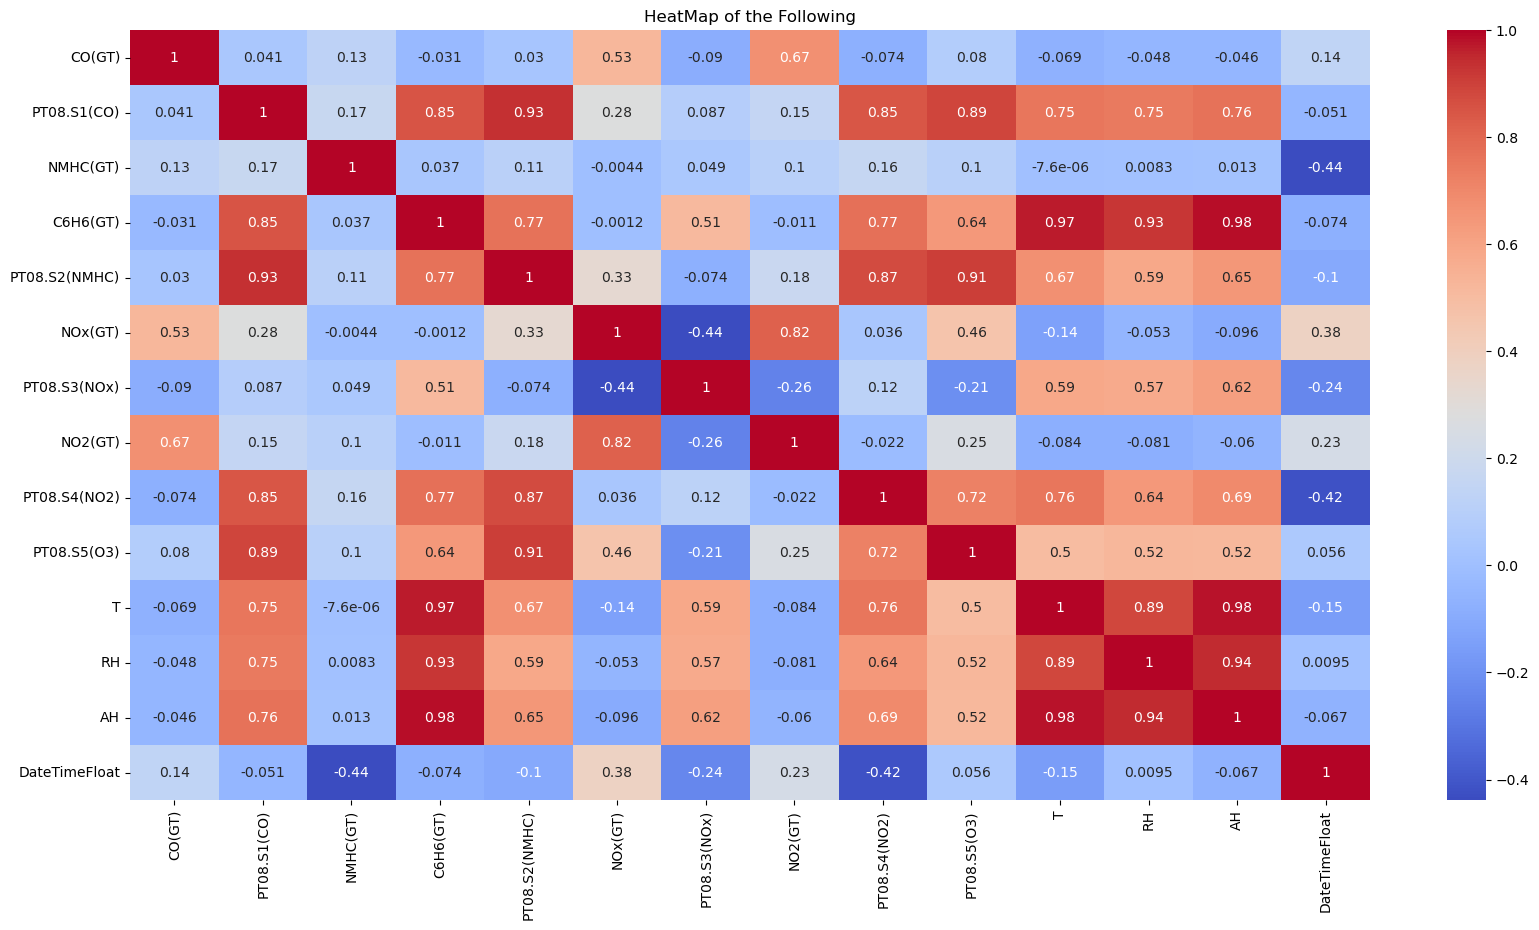

In [37]:
plt.figure(figsize=(20,10))
sns.heatmap(df4.corr(),annot=True,cmap='coolwarm')
plt.title('HeatMap of the Following')
plt.show()

**Hint:** [Build a heatmap with Seaborn](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

## Part 2: Dimension Reduction

### Problem 5

please consider the **iris dataset**:


In [38]:
#Import the built-in dataset (Wine recognition) for this problem
import sklearn
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
print(sklearn.datasets.load_iris().DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [39]:
#laod the dataset
iris = datasets.load_iris()
X = pd.DataFrame(iris.data)
X.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [40]:
# laod the vector of target variable
y = iris.target

**TODO1:**

*  Determine first two principal component scores for the data set with eigenvalues and eigenvectors on the RAW data (without standardization). 

*  Note that you are expected to perform matrix multipication, eigen value calculation **only** with the package Numpy, and sorted eigenvalues and eigenvectors in descending order (i.e. $\lambda_{0} \geq \lambda_{1} \geq \lambda{2} \geq ... \geq \lambda_{n}$ so do the eigenvectors).

In [41]:
covariance_mat = np.cov(X.T)
eigenvalues,eigenvectors = np.linalg.eig(covariance_mat)
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:,sorted_indices]

In [42]:
X_pca = X.dot(sorted_eigenvectors[:,:2])
print("First 2 components")
print(X_pca.head())

First 2 components
          0         1
0  2.818240 -5.646350
1  2.788223 -5.149951
2  2.613375 -5.182003
3  2.757022 -5.008654
4  2.773649 -5.653707


In [43]:
print("Eigen Values:")
print(sorted_eigenvalues)
print("EigenValues:")
print(sorted_eigenvectors)

Eigen Values:
[4.22824171 0.24267075 0.0782095  0.02383509]
EigenValues:
[[ 0.36138659 -0.65658877 -0.58202985  0.31548719]
 [-0.08452251 -0.73016143  0.59791083 -0.3197231 ]
 [ 0.85667061  0.17337266  0.07623608 -0.47983899]
 [ 0.3582892   0.07548102  0.54583143  0.75365743]]


**Hint:** 

1. [Eigen value calculation with Numpy](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html)

2. [Sorting a Numpy array](https://sparkbyexamples.com/python/numpy-sort-arrays-examples/#:~:text=By%20Sorting%20a%20NumPy%20array,%5B12%208%206%205%5D.)

**TODO2:**

*  Perform the data standardization on the data without using any buit-in functions.

*  Determine the first two principal component scores with eigenvaues and eigenvectors on the standardized data by updataing your code form **TODO1**. (i.e. your code from **TODO** one should not be changed; you should only add a cell of code for standardization.)

In [44]:
X_standardized = (X-X.mean())/X.std()


In [45]:
covariance_mat_std = np.cov(X_standardized.T)
eigenvalues_std,eigenvectors_std = np.linalg.eig(covariance_mat_std)
sorted_std = np.argsort(eigenvalues_std)[::-1]
sorted_std_eigenvalues = eigenvalues_std[sorted_std]
sorted_std_eigenvectors = eigenvectors_std[:,sorted_std]

In [46]:
X_pca_std = X_standardized.dot(sorted_std_eigenvectors[:,:3])

In [47]:
print(f"First Two components after standardization are: {X_pca_std.head()}")

First Two components after standardization are:           0         1         2
0 -2.257141 -0.478424 -0.127280
1 -2.074013  0.671883 -0.233826
2 -2.356335  0.340766  0.044054
3 -2.291707  0.595400  0.090985
4 -2.381863 -0.644676  0.015686


**TODO3:**

*  Use the built-in function called `PCA()` on the raw data to calculate the first two principal components.

*  For each of the components, indentify the explained variance, proportion variance, and cummulative proportion of variance.

* Compare your result with **TODO1**, are they same? (You might expect that you will have the same result wilth **TODO1**. However, `PCA()` function automatically does `x-mean()` transformation. Therefore, do not worry that your result from this one is different than the result performed from **TODO1**.)

**Hint**: 

* [PCA Python](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

In [48]:
X_standardized1 = (X-X.mean())/X.std()
pca = PCA(n_components=3)
X_spca = pca.fit_transform(X_standardized1) 

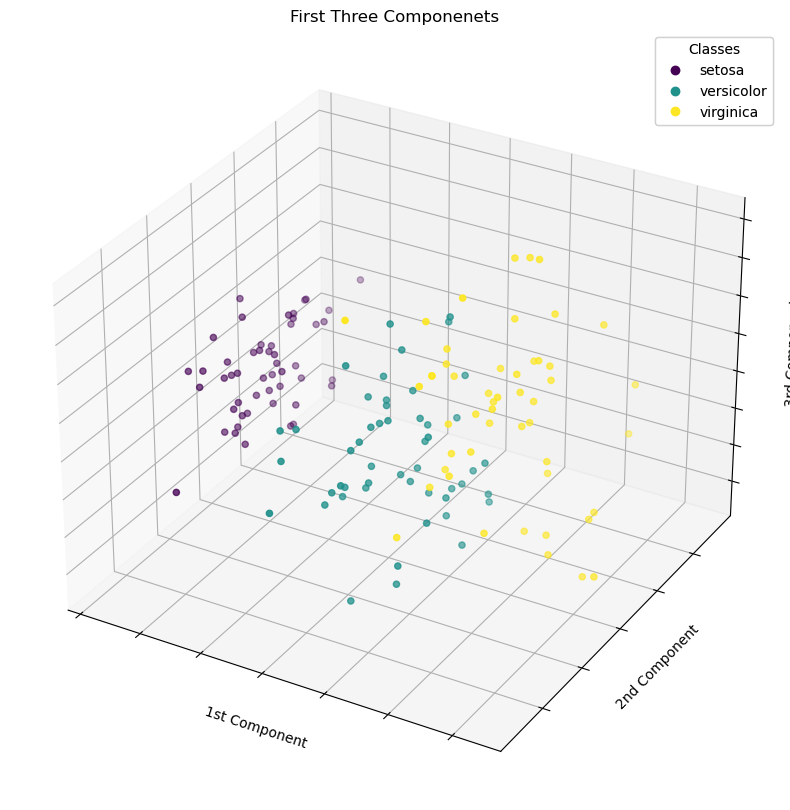

In [49]:
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111,projection='3d')

scatter = ax.scatter(
    X_spca[:,0],
    X_spca[:,1],
    X_spca[:,2],
    c=iris.target,
    cmap='viridis',
)

ax.set_title("First Three Componenets")
ax.set_xlabel('1st Component')
ax.set_ylabel('2nd Component')
ax.set_zlabel('3rd Component')

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

legend1 = ax.legend(scatter.legend_elements()[0],
                    iris.target_names.tolist(),
                    loc = 'upper right',title='Classes')

ax.add_artist(legend1)
plt.show()

**TODO4:**

*  Use the built-in function called `preprocessing.StandardScaler` and `PCA` to calculate the first two principal components. 

*  For each of the components, determine the explained variance, propotion variance, and cummulative proportion of variance.

* Compare your result with **TODO2**, are they same?

**Hint**: [Data Standardization in Python](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca1 = PCA(n_components=3)
X_scaled_pca = pca1.fit_transform(X_scaled)

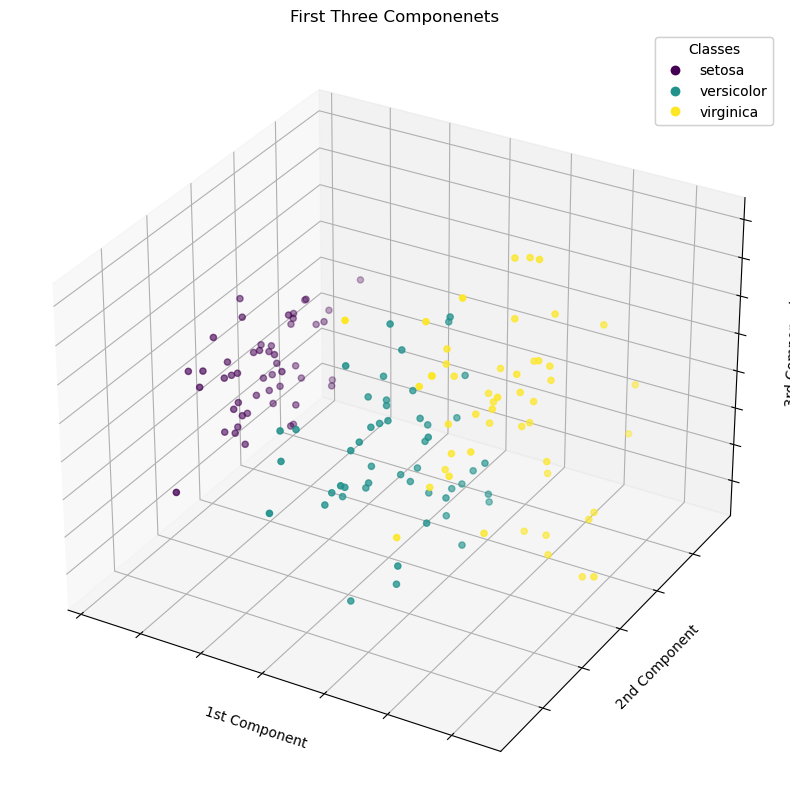

In [51]:
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111,projection='3d')

scatter = ax.scatter(
    X_scaled_pca[:,0],
    X_scaled_pca[:,1],
    X_scaled_pca[:,2],
    c=iris.target,
    cmap='viridis',
)

ax.set_title("First Three Componenets")
ax.set_xlabel('1st Component')
ax.set_ylabel('2nd Component')
ax.set_zlabel('3rd Component')

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

legend1 = ax.legend(scatter.legend_elements()[0],
                    iris.target_names.tolist(),
                    loc = 'upper right',title='Classes')

ax.add_artist(legend1)
plt.show()

**TODO5:**

*  Integrate from **TODO1** to **TODO4**, why is it important to standardize(normalize) variables before perfroming PCA

*  Plot the records on 2D plane defined by the first two PCA components calcualted with standardized data and dffierentiate them using by **target** (i.e. $y$).

*  Make some meaningful interpretation about the plot.

In [52]:
X1 = pd.DataFrame(iris.data)
X1.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [53]:
y1 = iris.target
y1

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [54]:
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)
pca2 = PCA(n_components=3)
X1_scaled_pca = pca2.fit_transform(X1_scaled)

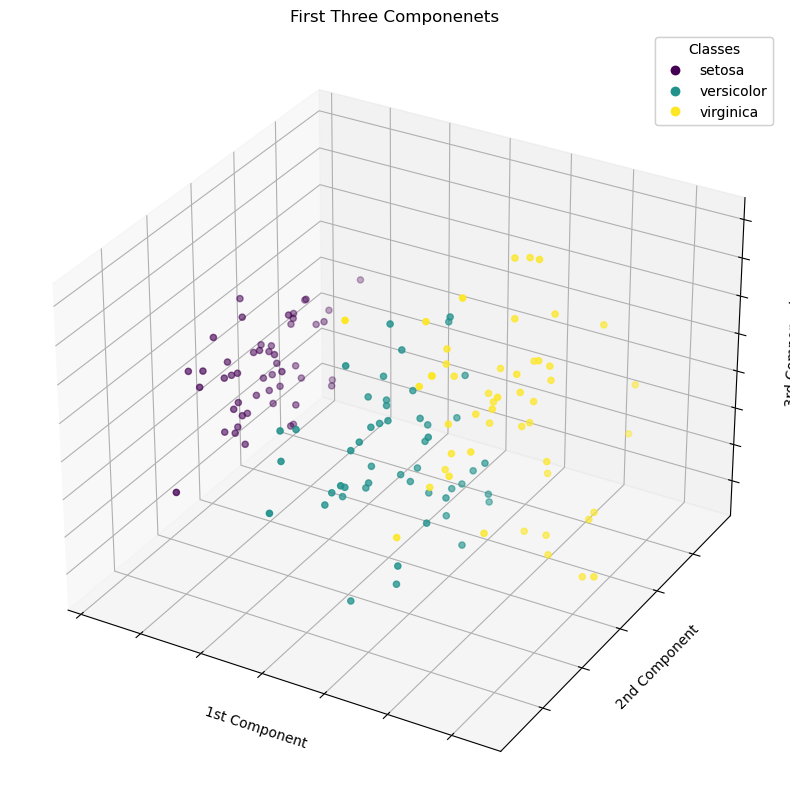

In [55]:
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111,projection='3d')

scatter = ax.scatter(
    X1_scaled_pca[:,0],
    X1_scaled_pca[:,1],
    X1_scaled_pca[:,2],
    c=iris.target,
    cmap='viridis',
)

ax.set_title("First Three Componenets")
ax.set_xlabel('1st Component')
ax.set_ylabel('2nd Component')
ax.set_zlabel('3rd Component')

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

legend1 = ax.legend(scatter.legend_elements()[0],
                    iris.target_names.tolist(),
                    loc = 'upper right',title='Classes')

ax.add_artist(legend1)
plt.show()

In [56]:
explained_variance = pca2.explained_variance_
propotion_variance = pca2.explained_variance_ratio_
cummulative_variance = np.cumsum(pca2.explained_variance_ratio_)
print(f"explained Variance : {explained_variance}")
print(f"Propotion Variance : {propotion_variance}")
print(f"Cummulative Variance : {cummulative_variance}")


explained Variance : [2.93808505 0.9201649  0.14774182]
Propotion Variance : [0.72962445 0.22850762 0.03668922]
Cummulative Variance : [0.72962445 0.95813207 0.99482129]


### Problem 6

**Dataset:** Life Expectancy

**Introduction:** The above dataset gives life expectancy related data for 37 countries in2014. 

Consider only the following variables in your analysis: 'GDP', 'Income composition of resources', 'Schooling', and 'Total expenditure'.

In [57]:
#Import useful package
from sklearn.manifold import MDS


df = pd.read_csv("Life Expectancy.csv") 
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2014,Developing,59.9,271,64,0.01,73.523582,62.0,492,...,58,8.18,62,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
1,Australia,2014,Developed,82.7,6,1,9.71,10769.363050,91.0,340,...,92,9.42,92,0.1,62214.691200,2346694.0,0.6,0.6,0.936,20.4
2,Austria,2014,Developed,81.4,66,0,12.32,8350.193523,98.0,117,...,98,11.21,98,0.1,51322.639970,8541575.0,1.8,2.0,0.892,15.9
3,Bangladesh,2014,Developing,71.4,132,98,0.01,10.446403,97.0,289,...,97,2.82,97,0.1,184.565430,15945279.0,18.1,18.6,0.570,10.0
4,Belgium,2014,Developed,89.0,76,0,12.60,7163.348923,98.0,70,...,99,1.59,99,0.1,47439.396840,112957.0,1.0,1.0,0.890,16.3


In [58]:
select_columns = ['GDP','Income composition of resources','Schooling','Total expenditure','Country','Status']
df_select = df[select_columns].dropna()

**TODO1:**

* Standardize the numeric variables in the given data frame
* Run MDS() (Multi Dimensional Scaling) on the standardized data 
  - **Hint:** n_components = 2
* Plot data points on a 2D plane defined by the first two components
* Use color to differentiate the statues of each country with legend
* Use text label to specify the country name for each point
* Comment your findings from the graph

**Hint:**  [MDS Python](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html)

In [59]:
scaler2 = StandardScaler()
df_select_scaled = scaler.fit_transform(df_select[['GDP','Income composition of resources','Schooling','Total expenditure']])

In [60]:
mds = MDS(n_components=2,random_state=42,dissimilarity='euclidean')
mds_results = mds.fit_transform(df_select_scaled)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_mds.py:299: FutureWarning:

The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.



In [61]:
df_mds = pd.DataFrame(mds_results,columns=['MDS1','MDS2'])
df_mds['Country'] = df_select['Country'].values
df_mds['Status'] = df_select['Status'].values

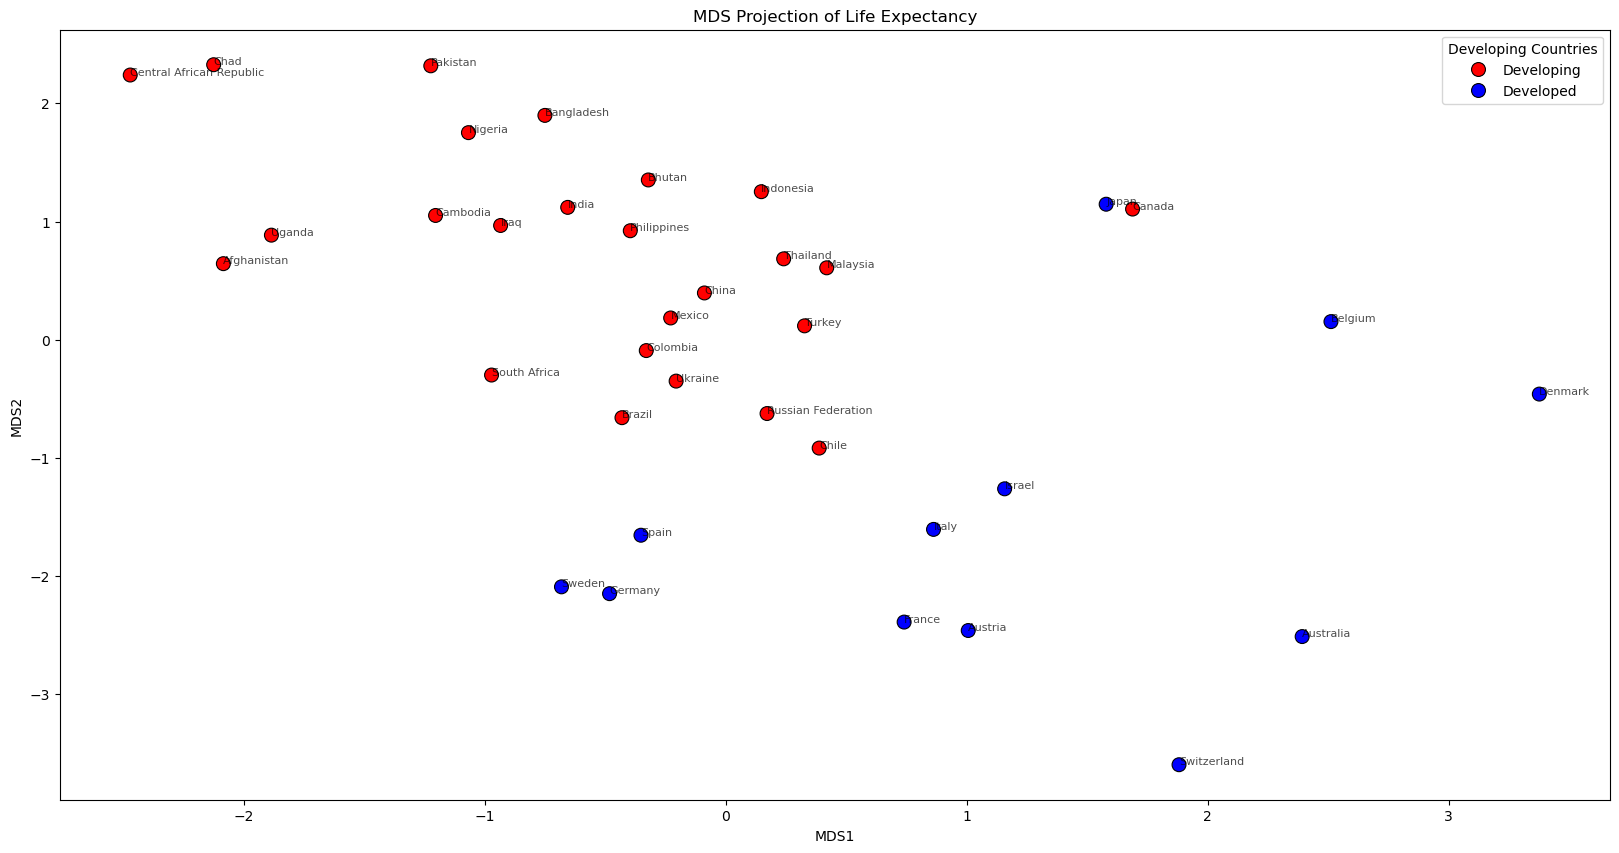

In [62]:
plt.figure(figsize=(20,10))
sns.scatterplot(x='MDS1',y='MDS2',hue='Status',data=df_mds,palette={'Developed':'blue','Developing':'red'},s=100,edgecolor='black')

for i,row in df_mds.iterrows():
    plt.text(row['MDS1'],row['MDS2'],row['Country'],fontsize=8,alpha=0.7)
    
plt.title('MDS Projection of Life Expectancy')
plt.xlabel('MDS1')
plt.ylabel('MDS2')
plt.legend(title='Developing Countries')
plt.show()

### Problem 7

Dataset: Game of thrones Books

Introduction: If you haven't heard of Game of Thrones, then you must be really good at hiding. Game of Thrones is the hugely popular television series by HBO based on the (also) hugely popular book series A Song of Ice and Fire by George R.R. Martin. You need to analyze the co-occurrence network of the characters in the Game of Thrones books. Here, two characters are considered to co-occur if their names appear in the vicinity of 15 words from one another in the books.

This dataset (5 files attached in zip file) constitutes a network and is given as a text file describing the edges between characters, with some attributes attached to each edge.

Loading the required libraries

In [63]:
pip install pyvis

Note: you may need to restart the kernel to use updated packages.


In [72]:
!pip install pyvis
import pyvis
import networkx as nx
from pyvis.network import Network


Traceback (most recent call last):
  File "/opt/anaconda3/bin/pip", line 6, in <module>
    from pip._internal.cli.main import main
  File "/opt/anaconda3/lib/python3.11/site-packages/pip/_internal/cli/main.py", line 11, in <module>
    from pip._internal.cli.autocompletion import autocomplete
  File "/opt/anaconda3/lib/python3.11/site-packages/pip/_internal/cli/autocompletion.py", line 10, in <module>
    from pip._internal.cli.main_parser import create_main_parser
  File "/opt/anaconda3/lib/python3.11/site-packages/pip/_internal/cli/main_parser.py", line 9, in <module>
    from pip._internal.build_env import get_runnable_pip
  File "/opt/anaconda3/lib/python3.11/site-packages/pip/_internal/build_env.py", line 18, in <module>
    from pip._internal.cli.spinners import open_spinner
  File "/opt/anaconda3/lib/python3.11/site-packages/pip/_internal/cli/spinners.py", line 9, in <module>
    from pip._internal.utils.logging import get_indentation
  File "/opt/anaconda3/lib/python3.11/site-

ImportError: cannot import name 'gcd' from 'fractions' (/opt/anaconda3/lib/python3.11/fractions.py)

**TODO1:**

- Load data for the all the books of Game of Thrones (Merge all files into one and create a dataframe)
- Select only the rows which has weight more than 10

In [71]:
import fractions
print(fractions.__file__)

/opt/anaconda3/lib/python3.11/fractions.py


**TODO2:**
Load the dataframe as networkx graph

Hint: [Network analysis in python](https://networkx.org/documentation/stable/reference/generated/networkx.convert_matrix.from_pandas_edgelist.html)

In [ ]:
print("No of unique characters:", len(G.nodes))
print("No of connections:", len(G.edges))

**TODO3:**

Create viz network
Hint: [Use Pyvis](https://pyvis.readthedocs.io/en/latest/)

PS: If you are unable to view the network, export it to a html file and upload the html file along with the homework submissions in canvas.